In [2]:
!pip -q install insightface onnxruntime-gpu "opencv-python<4.10"

In [3]:
import os
print(os.listdir("/kaggle/input/fairface-race/FairFace Race/val_aligned"))

['Black', 'Latino_Hispanic', 'White', 'Asian', 'Middle Eastern', 'Indian']


In [4]:
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# hard-coded dataset paths
TRAIN_DIR = Path("/kaggle/input/fairface-race/FairFace Race/train_aligned")
VAL_DIR   = Path("/kaggle/input/fairface-race/FairFace Race/val_aligned")

print("Train path:", TRAIN_DIR)
print("Val path  :", VAL_DIR)

# transforms
IMG_SIZE = 224
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# datasets
train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(root=str(VAL_DIR),   transform=val_tf)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# check
print("Classes:", train_ds.classes)
print("Train samples:", len(train_ds))
print("Val samples  :", len(val_ds))

Train path: /kaggle/input/fairface-race/FairFace Race/train_aligned
Val path  : /kaggle/input/fairface-race/FairFace Race/val_aligned
Classes: ['Asian', 'Black', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'White']
Train samples: 24000
Val samples  : 2763


Classes: ['Asian', 'Black', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'White']

Train counts per class:
  Asian            : 4000
  Black            : 4000
  Indian           : 4000
  Latino_Hispanic  : 4000
  Middle Eastern   : 4000
  White            : 4000

Val counts per class:
  Asian            : 437
  Black            : 225
  Indian           : 467
  Latino_Hispanic  : 660
  Middle Eastern   : 258
  White            : 716


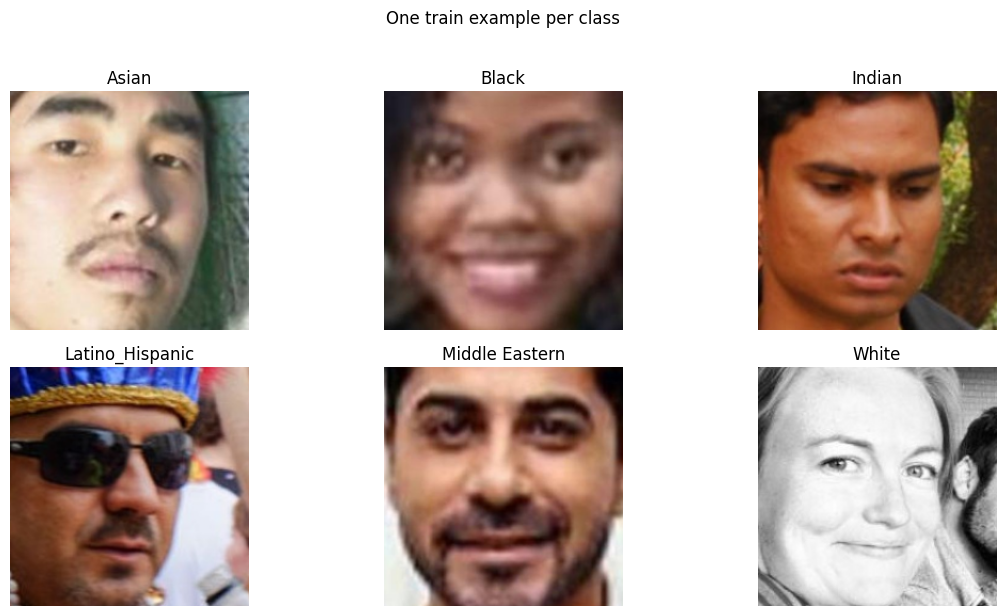

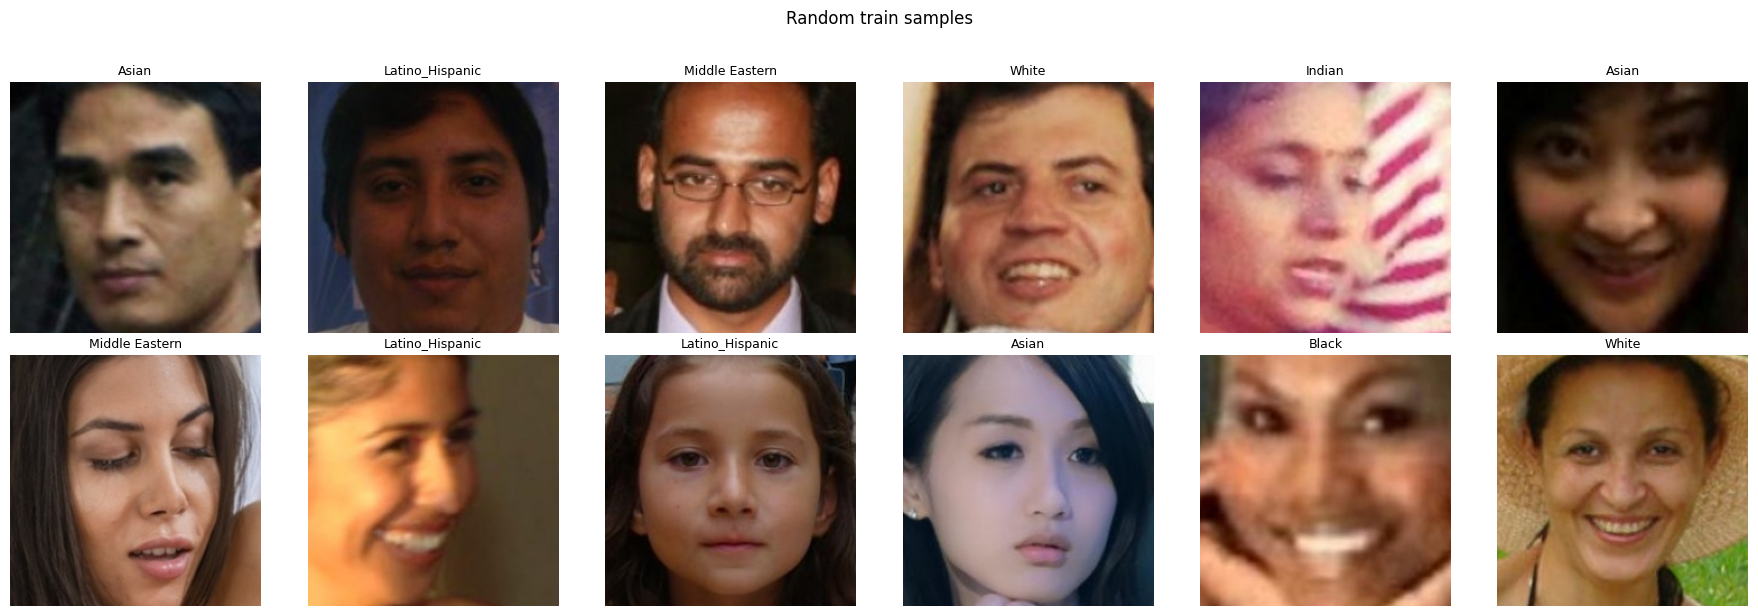

In [5]:
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

TRAIN_DIR = Path("/kaggle/input/fairface-race/FairFace Race/train_aligned")
VAL_DIR   = Path("/kaggle/input/fairface-race/FairFace Race/val_aligned")

IMG_SIZE = 224
train_tf_vis = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])
val_tf_vis = train_tf_vis

train_ds_vis = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tf_vis)
val_ds_vis   = datasets.ImageFolder(root=str(VAL_DIR),   transform=val_tf_vis)

classes = train_ds_vis.classes
print("Classes:", classes)

# --- class counts
from collections import Counter
train_counts = Counter([y for _, y in train_ds_vis.samples])
val_counts   = Counter([y for _, y in val_ds_vis.samples])

print("\nTrain counts per class:")
for i,c in enumerate(classes):
    print(f"  {c:16s} : {train_counts[i]}")

print("\nVal counts per class:")
for i,c in enumerate(classes):
    print(f"  {c:16s} : {val_counts[i]}")

# --- show 1 example per class (train)
plt.figure(figsize=(12, 6))
for i, c in enumerate(classes):
    # find first index with label i
    idx = next(k for k,(_,y) in enumerate(train_ds_vis.samples) if y == i)
    img, y = train_ds_vis[idx]
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    plt.subplot(2, (len(classes)+1)//2, i+1)
    plt.imshow(img); plt.title(c); plt.axis("off")
plt.suptitle("One train example per class", y=1.02)
plt.tight_layout()
plt.show()

# --- show a small grid of random train images
N = 12  # change to see more/less
idxs = random.sample(range(len(train_ds_vis)), min(N, len(train_ds_vis)))
cols = 6
rows = int(np.ceil(len(idxs)/cols))
plt.figure(figsize=(3*cols, 3*rows))
for j, idx in enumerate(idxs):
    img, y = train_ds_vis[idx]
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    plt.subplot(rows, cols, j+1)
    plt.imshow(img); plt.title(classes[y], fontsize=9); plt.axis("off")
plt.suptitle("Random train samples", y=1.02)
plt.tight_layout()
plt.show()

# ------------- OPTIONAL: dump ALL images as tiled sheets (can be large) -------------
# This saves grids per class to /kaggle/working (don’t display inline to avoid lag).
# from torchvision.utils import make_grid, save_image
# import torch, math, os
# OUT = Path("/kaggle/working/preview_grids")
# OUT.mkdir(exist_ok=True)
# per_sheet = 64
# for ci, cname in enumerate(classes):
#     # collect all indices for this class
#     idxs = [k for k,(_,y) in enumerate(train_ds_vis.samples) if y==ci]
#     # pack per_sheet images into grids
#     for start in range(0, len(idxs), per_sheet):
#         batch = []
#         for idx in idxs[start:start+per_sheet]:
#             x,_ = train_ds_vis[idx]
#             batch.append(x)
#         if not batch: continue
#         grid = make_grid(torch.stack(batch), nrow=8, padding=2)
#         save_image(grid, OUT/f"{cname}_train_{start:06d}.png")
# print("Saved tiled previews (optional) to /kaggle/working/preview_grids")


In [6]:
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Paths (from your screenshot)
TRAIN_DIR = Path("/kaggle/input/fairface-race/FairFace Race/train_aligned")
VAL_DIR   = Path("/kaggle/input/fairface-race/FairFace Race/val_aligned")

# Transforms
IMG_SIZE = 224
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [7]:
# Data
BATCH, NUM_WORK = 64, 2
train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORK, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORK, pin_memory=True)

classes = train_ds.classes
num_classes = len(classes)
print("Classes:", classes)

Classes: ['Asian', 'Black', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'White']


In [9]:
# Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

# Optim, sched, AMP
opt  = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5)
crit = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]
/tmp/ipykernel_36/3513363000.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [10]:
# --- Updated AMP-friendly training & validation (PyTorch >=2.1) ---

import torch
from torch.amp import autocast, GradScaler
from contextlib import nullcontext

BEST_PATH = "/kaggle/working/fairface_resnet18.pt"
best_acc  = 0.0
EPOCHS    = 10

# AMP setup
amp_enabled = (device == "cuda")
amp_dtype   = torch.float16            # good default for T4/P100 on Kaggle
scaler      = GradScaler(enabled=amp_enabled)

def validate():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        ctx = autocast("cuda", dtype=amp_dtype, enabled=amp_enabled) if amp_enabled else nullcontext()
        with ctx:
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                pred   = logits.argmax(1)
                correct += (pred == yb).sum().item()
                total   += yb.numel()
    return correct/total if total else 0.0

for ep in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)

        ctx = autocast("cuda", dtype=amp_dtype, enabled=amp_enabled) if amp_enabled else nullcontext()
        with ctx:
            logits = model(xb)
            loss   = crit(logits, yb)

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            opt.step()

    sched.step()
    acc = validate()
    print(f"Epoch {ep}/{EPOCHS} | val acc = {acc:.3f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(
            {"state_dict": model.state_dict(),
             "classes": classes,
             "img_size": IMG_SIZE},
            BEST_PATH
        )
        print(f"  ↳ Saved best to {BEST_PATH} (acc={best_acc:.3f})")

Epoch 1/10 | val acc = 0.577
  ↳ Saved best to /kaggle/working/fairface_resnet18.pt (acc=0.577)
Epoch 2/10 | val acc = 0.661
  ↳ Saved best to /kaggle/working/fairface_resnet18.pt (acc=0.661)
Epoch 3/10 | val acc = 0.688
  ↳ Saved best to /kaggle/working/fairface_resnet18.pt (acc=0.688)
Epoch 4/10 | val acc = 0.659
Epoch 5/10 | val acc = 0.709
  ↳ Saved best to /kaggle/working/fairface_resnet18.pt (acc=0.709)
Epoch 6/10 | val acc = 0.695
Epoch 7/10 | val acc = 0.689
Epoch 8/10 | val acc = 0.673
Epoch 9/10 | val acc = 0.628
Epoch 10/10 | val acc = 0.552


In [11]:
# Optional: stronger face detector (RetinaFace). Enable Internet in Settings first.
!pip -q install insightface onnxruntime-gpu "opencv-python<4.10"

In [13]:
# Upload + detect + classify (DP-aware checkpoint loading)

import io, os, cv2, torch, torch.nn as nn
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import models, transforms as T
import torch.nn.functional as F
from IPython.display import display
import ipywidgets as widgets

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Load your trained model (handles DataParallel checkpoints) ----
CKPT = "/kaggle/working/fairface_resnet18.pt"   # path you saved earlier
ckpt = torch.load(CKPT, map_location=device)
classes = ckpt["classes"]
IMG_SIZE = ckpt.get("img_size", 224)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))

sd = ckpt["state_dict"]
# strip "module." if present (from nn.DataParallel)
if any(k.startswith("module.") for k in sd.keys()):
    sd = {k.replace("module.", "", 1): v for k, v in sd.items()}
model.load_state_dict(sd, strict=True)

model.to(device).eval()

prep = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def classify_pil(pil_img: Image.Image):
    with torch.no_grad():
        x = prep(pil_img).unsqueeze(0).to(device)
        prob = F.softmax(model(x), dim=1)[0]
        cid  = int(prob.argmax().item())
        conf = float(prob[cid].item())
        return classes[cid], conf

# ---- Face detector: try RetinaFace, else fallback to Haar cascade ----
use_retina = False
try:
    from insightface.app import FaceAnalysis
    app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider","CPUExecutionProvider"])
    app.prepare(ctx_id=0, det_size=(640,640))
    use_retina = True
except Exception:
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    face_cascade = cv2.CascadeClassifier(cascade_path)

def detect_faces_bboxes(img_bgr):
    h, w = img_bgr.shape[:2]
    if use_retina:
        faces = app.get(img_bgr)
        boxes = []
        for f in faces:
            x1,y1,x2,y2 = map(int, f.bbox)
            x1,y1 = max(0,x1), max(0,y1)
            x2,y2 = min(w-1,x2), min(h-1,y2)
            boxes.append((x1,y1,x2,y2))
        return boxes
    else:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        dets = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(40,40))
        return [(x, y, x+w, y+h) for (x, y, w, h) in dets]

# ---- Upload widget ----
uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(widgets.HTML("<b>Upload an image (jpg/png):</b>"))
display(uploader)

run_btn = widgets.Button(description="Detect & Classify", button_style="success")
out = widgets.Output()
display(run_btn, out)

def _get_uploaded_bytes(uploader):
    if isinstance(uploader.value, dict):
        name, item = next(iter(uploader.value.items()))
        return name, item["content"]
    elif isinstance(uploader.value, (tuple, list)) and len(uploader.value) > 0:
        item = uploader.value[0]
        return item["name"], item["content"]
    return None, None

@out.capture(clear_output=True)
def on_click(_):
    fname, content = _get_uploaded_bytes(uploader)
    if not content:
        print("Please upload an image first.")
        return

    save_path = Path("/kaggle/working") / f"uploaded_{fname}"
    with open(save_path, "wb") as f:
        f.write(content)

    img_bgr = cv2.imread(str(save_path))
    if img_bgr is None:
        print("Failed to read the uploaded image.")
        return

    boxes = detect_faces_bboxes(img_bgr)
    if not boxes:
        print("No faces detected.")
        return

    for (x1,y1,x2,y2) in boxes:
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0: 
            continue
        pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        label, conf = classify_pil(pil)
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img_bgr, f"{label} ({conf*100:.1f}%)",
                    (x1, max(0,y1-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)

    from matplotlib import pyplot as plt
    plt.figure(figsize=(6,6)); plt.axis("off")
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.show()

    out_path = Path("/kaggle/working") / "prediction_overlay.png"
    cv2.imwrite(str(out_path), img_bgr)
    print(f"Saved result to: {out_path}")

run_btn.on_click(on_click)


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 70685.07KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

HTML(value='<b>Upload an image (jpg/png):</b>')

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Detect & Classify', style=ButtonStyle())

Output()